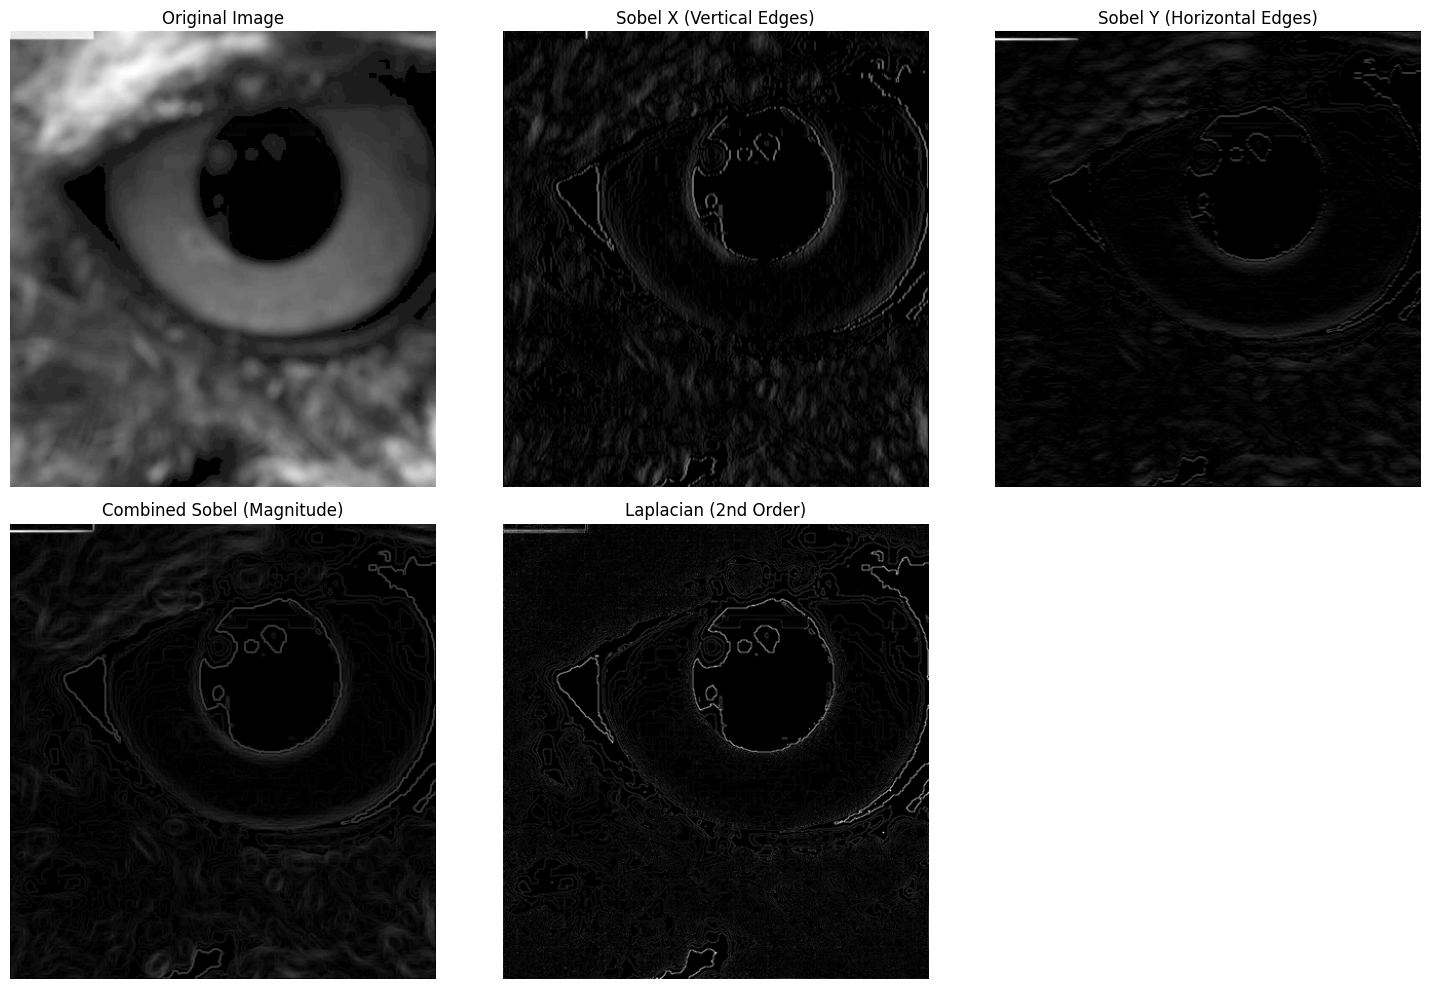

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read the image in Grayscale
# Replace 'moon.jfif' with your actual image path in Colab
img = cv2.imread('/content/unsharpe-iamge.png', cv2.IMREAD_GRAYSCALE)

# Step 2: Apply 1st Order Derivative (Sobel)
# dx=1, dy=0 means Sobel X. ksize=3 is the 3x3 matrix.
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

# dx=0, dy=1 means Sobel Y.
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Combine them using the magnitude formula
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

# Step 3: Apply 2nd Order Derivative (Laplacian)
laplacian = cv2.Laplacian(img, cv2.CV_64F)

# Step 4: Plot everything to observe the differences
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
# Using absolute values to display the negative slopes properly
plt.imshow(np.abs(sobel_x), cmap='gray')
plt.title("Sobel X (Vertical Edges)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(np.abs(sobel_y), cmap='gray')
plt.title("Sobel Y (Horizontal Edges)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel_combined, cmap='gray')
plt.title("Combined Sobel (Magnitude)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title("Laplacian (2nd Order)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 🔹 MRI Image URL (you can replace)
url = "https://cf-images.us-east-1.prod.boltdns.net/v1/jit/6168375534001/adef4c6d-9218-4c82-859b-1274e307545b/main/1280x720/7s7ms/match/image.jpg"

# Download image
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

img_array = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

# 🔹 Apply Gaussian Blur
blur = cv2.GaussianBlur(img, (5,5), 0)

# 🔹 Apply Canny Edge Detection
edges = cv2.Canny(blur, 50, 150)

# 🔹 Display Results
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original MRI Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(blur, cmap='gray')
plt.title("Blurred Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

plt.show()

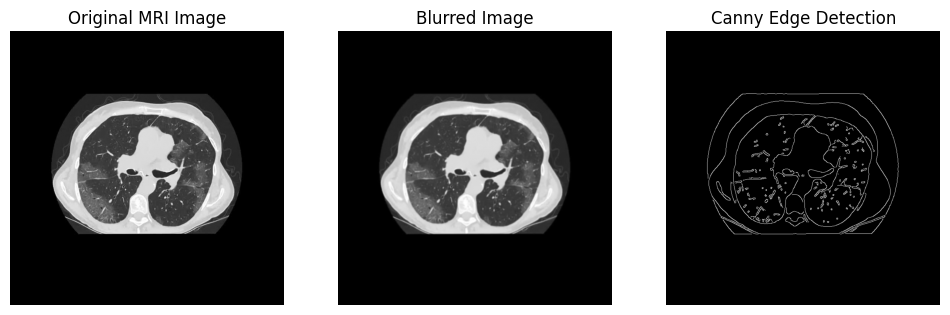